#### Word2Vec

Worc2vec is a technique for natura language processing published in 2013 by Google. The word2vec algorithm uses a neural network model to learn word associations from a large corpus of text. Once trained, such a model can detect synonymous words or suggest additional words for a partial sentences. As the name implies, word2vec represents each distinct word with a particular list of numbers called a vector.

##### Core Idea:
**Words that appear in similar contexts have similar meanings**

Example: 
- King and queen appear in similar context -> Vectors become similar
- Apple(fruit) vs apple (Company) -> same vector(limitation)

##### How Word2Vec Works

Word2Vec uses a **shallow neural network** (1 hidden layer) to learn embeddings from text.

Instead of predicting labels, it learns by:
- Predicting words from context OR
- Predicting context from a word

##### Two main architectures
1. CBOW : Predicts target word using surrounding words
    - Faster
    - Works well with small datasets

*Example:*
```
context: "I love _____ very much"
Target: "NLP"
```

2. Skip-gram: Predicts context words from a target word
    - Better for rare words
    - More accurate
    - Slower
    
*Example:*
```
Input: "NLP"
Output: ["I", "love", "very", "much"]
```

##### Word2vec vs Modern models

| Feature       | Word2Vec | BERT / GPT |
| ------------- | -------- | ---------- |
| Context-aware | ❌ No     | ✅ Yes      |
| Speed         | ✅ Fast   | ❌ Slower   |
| Accuracy      | Medium   | High       |


##### Famous Property (Vector Arithmetic)
Word2vec captures relationships:
```
king - man + woman = queen
```
this works because embeddings encode
- Gender
- Royalty
- Semantic Relationships

##### Advantages
- Captures semantic meaning
- Low dimensional dense vectors
- Efficient to train
- Works well for many NLP tasks

##### Limitations
- Same word -> same vector (No context awareness)
- Needs large corpus
- Cannot handle polysemy

##### Word2vec without Gensim (Pytorch Example)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sample data
sentences = [["i", "love", "nlp"], ["nlp", "is", "fun"]]

# Build vocabulary
vocab = list(set(word for sentence in sentences for word in sentence))
word_to_ix = {word: i for i, word in enumerate(vocab)}

# Generate training data (Skip-gram)
pairs = []
window_size = 2

for sentence in sentences:
    for i, word in enumerate(sentence):
        for j in range(max(0, i-window_size), min(len(sentence), i+window_size+1)):
            if i != j:
                pairs.append((word, sentence[j]))

# Model
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, target):
        return self.embeddings(target)

model = Word2Vec(len(vocab), 10)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop (simplified)
for epoch in range(100):
    for target, context in pairs:
        target_idx = torch.tensor([word_to_ix[target]])
        context_idx = torch.tensor([word_to_ix[context]])

        optimizer.zero_grad()
        output = model(target_idx)
        loss = ((output - model(context_idx))**2).sum()
        loss.backward()
        optimizer.step()

# Get embedding
print(model.embeddings.weight)

Parameter containing:
tensor([[-0.3425, -0.2804, -0.2614, -0.0741,  0.2484, -0.4607,  0.2465, -0.9922,
         -0.7834, -0.0558],
        [-0.3412, -0.2917, -0.2648, -0.0738,  0.2535, -0.4645,  0.2422, -1.0011,
         -0.7768, -0.0573],
        [-0.3412, -0.2917, -0.2648, -0.0738,  0.2535, -0.4645,  0.2422, -1.0011,
         -0.7768, -0.0573],
        [-0.3439, -0.2679, -0.2576, -0.0745,  0.2428, -0.4566,  0.2513, -0.9822,
         -0.7906, -0.0541],
        [-0.3439, -0.2679, -0.2576, -0.0745,  0.2428, -0.4566,  0.2513, -0.9822,
         -0.7906, -0.0541]], requires_grad=True)


##### Applications fo Word2vec
- Text Similarity
- Recommendation System
- Chatbots
- Sentiment Analysis
- Search Engines

##### Average Word2vec

Average word2vec is a simple technique where you:
- Take the word2vec vectors of all words in a sentence/document
- Compute their average (mean)
- Use that single vector to represent the whole sentence

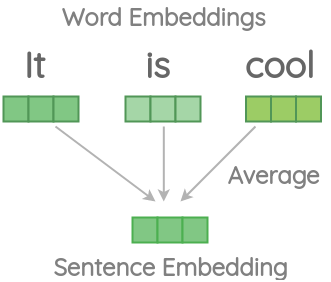 

Each word has a vector like:
- "I" -> [0.2, 0.1, ...]
- "love" -> [0.5, 0.6 ....]
- "NLP" -> [0.8, 0.7, ....]

**Average word2vec:**
```
Sentence Vector = (v1 + v2 + v3 + ... + vn)/n
```

#### Google Gensim Example
**No official GENSIM Support for Python 3.14.x version**

In [1]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")
vec_love = model["love"]

ModuleNotFoundError: No module named 'gensim'